This notebook goes along with the Building a KNN model with Scikit-learn tutorial.

In [1]:
import pandas as pd

#read in the data using pandas
df = pd.read_csv('data/diabetes_data.csv')

#check data has been read in properly
df.head()

,pregnancies,glucose,diastolic,triceps,insulin,bmi,dpf,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
#check number of rows and columns in dataset
df.shape

(768, 9)

In [3]:
#create a dataframe with all training data except the target column
X = df.drop(columns=['diabetes'])

#check that the target variable has been removed
X.head()

,pregnancies,glucose,diastolic,triceps,insulin,bmi,dpf,age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [4]:
#separate target values
y = df['diabetes'].values

#view target values
y[0:5]

array([1, 0, 1, 0, 1], dtype=int64)

In [5]:
from sklearn.model_selection import train_test_split

#split dataset into train and test data
# 80%-20% train/test split
# choose a random_state if you want to produce same result at every run, omit for final report
# Using stratify=y ensures that: The proportion of each class in the training and test sets 
# matches the proportion in the full dataset. You avoid imbalanced splits, 
# which could lead to misleading model performance.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=1, stratify=y)

In [6]:
from sklearn.neighbors import KNeighborsClassifier

# Create KNN classifier
knn = KNeighborsClassifier(n_neighbors = 3)

# Fit the classifier to the data
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [7]:
#show first 5 model predictions on the test data
knn.predict(X_test)[0:5]
print(knn.predict(X_test)[0:5])
print(y_test[0:5])

[0 0 0 0 1]
[0 0 0 0 0]


In [8]:
#check accuracy of our model on the test data
# Accuracy = Number of correct predictions/Total number of predictions
knn.score(X_test, y_test)

0.6688311688311688

In [24]:
from sklearn.metrics import classification_report, accuracy_score
# Report precision, recall, and more
# F1 Score=2(Precision⋅Recall/Precision+Recall)
# It’s the harmonic mean of precision and recall—not the average—so 
# it penalizes extreme values more harshly.

# Precision tells you: Of all predicted positives, how many were correct?
# Recall tells you: Of all actual positives, how many did we catch?
#F1 Score balances both: How well are we doing overall at identifying positives without too many false alarms?
y_pred = knn.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.75      0.75       100
           1       0.53      0.52      0.52        54

    accuracy                           0.67       154
   macro avg       0.64      0.63      0.63       154
weighted avg       0.67      0.67      0.67       154



In [9]:
from sklearn.model_selection import cross_val_score
import numpy as np

#create a new KNN model
knn_cv = KNeighborsClassifier(n_neighbors=3)

#train model with cv of 5 (5-fold) 
cv_scores = cross_val_score(knn_cv, X, y, cv=5)

#print each cv score (accuracy) and average them
print(cv_scores)
print('cv_scores mean:{}'.format(np.mean(cv_scores)))

[0.68181818 0.69480519 0.75324675 0.75163399 0.68627451]
cv_scores mean:0.7135557253204311


In [10]:
from sklearn.model_selection import GridSearchCV

#create new a knn model
knn2 = KNeighborsClassifier()

#create a dictionary of all values we want to test for n_neighbors
param_grid = {'n_neighbors': np.arange(1, 25)}

#use gridsearch to test all values for n_neighbors
knn_gscv = GridSearchCV(knn2, param_grid, cv=5)

#fit model to data
knn_gscv.fit(X, y)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])})

In [11]:
#check top performing n_neighbors value
knn_gscv.best_params_

{'n_neighbors': 14}

In [15]:
#check mean score for the top performing value of n_neighbors
knn_gscv.best_score_
knn_gscv.cv_results_['param_n_neighbors'].data
knn_gscv.cv_results_['mean_test_score']

array([0.66282149, 0.69404974, 0.71355573, 0.72135642, 0.72397929,
       0.72790086, 0.73571853, 0.7500382 , 0.74221204, 0.74480095,
       0.74873101, 0.7526356 , 0.75525847, 0.75785587, 0.73836686,
       0.74352771, 0.75137085, 0.74875647, 0.75008064, 0.74877345,
       0.74357864, 0.74614209, 0.7435362 , 0.7435362 ])

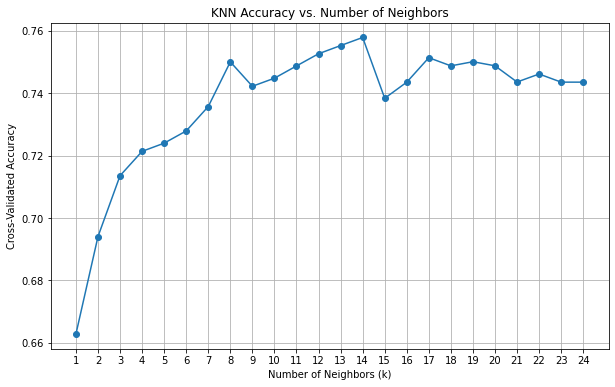

In [22]:
import matplotlib.pyplot as plt

# Extract mean cross-validated scores for each value of n_neighbors
neighbors = knn_gscv.cv_results_['param_n_neighbors'].data
mean_scores = knn_gscv.cv_results_['mean_test_score']

# Convert neighbors to a plain list of integers
neighbors = [int(k) for k in neighbors]



# Plotting
plt.figure(figsize=(10, 6))
plt.plot(neighbors, mean_scores, marker='o')
plt.title('KNN Accuracy vs. Number of Neighbors')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validated Accuracy')
plt.xticks(neighbors)
plt.grid(True)
plt.show()